## Initialization

In [1]:
import sys
sys.path.append('../src') # add the source code to the path

# These are the main files in MinScaffold/src/

import Driver
import Geometry
import Scaffold

# These libraries are used throughout the code

import math
import numpy as np
from random import random
import networkx as nx
import pickle as pk
import matplotlib.pyplot as plt
import shapely
from shapely.geometry import Polygon
import geopandas as gpd

In [8]:
## My data: the grocery stores
# Load in different distance measures
city_path = '../Distance Matrix Construction/'
city_code = 'dal'

# All the distance matrices to consider
dist_type_list = ['geodesic','walk','drive_osm','drive_gmaps_TrafUnaware']

dist_type = dist_type_list[0]

city_fname = f'{city_code}_{dist_type}_distance_data.npz'
with np.load(city_path+city_fname) as data:
    if dist_type == 'walk':
        W = data['dal_walk_distance_seconds']
        walk_speed = data['walk_speed']
    elif dist_type == 'geodesic':
        W = data['dal_geodesic_distance_seconds']
        walk_speed = data['walk_speed']

# Symmetrize
W = W+np.transpose(W)

# Put in units of minutes
W = W/60

[[    0.          9232.54821472 12308.32868523 10277.82423324]
 [ 9232.54821472     0.          7403.76409149  3552.26165674]
 [12308.32868523  7403.76409149     0.          3855.69248857]
 [10277.82423324  3552.26165674  3855.69248857     0.        ]]
[[    0.         18465.09642944 24616.65737047 20555.64846649]
 [18465.09642944     0.         14807.52818299  7104.52331348]
 [24616.65737047 14807.52818299     0.          7711.38497714]
 [20555.64846649  7104.52331348  7711.38497714     0.        ]]


In [9]:
#cut off data to avoid overly dense distance matrix
if dist_type == 'walk':
    Wsave = W
    W = np.round((W<180)*W)
    W = W - np.diag(np.diag(W))
elif dist_type == 'geodesic':
    Wsave = W
    W = np.round((W<120)*W)
    W = W - np.diag(np.diag(W))
elif (dist_type[0:5] == 'drive'):
    Wsave = W
    W = np.round((W<15)*W,1)
    W = W - np.diag(np.diag(W))

In [12]:
# Geography files
#
# - ZIP codes make more sense to provide in "resource ID agnostic" location
city_path_geo = '../Dallas/Food access_updated/'
pfname = 'geo_export_872fcb6c-fbde-4264-ae77-8858a604ed0e.shp'
zipfname = '../Dallas/Zip/dal_tx_zip.shp'

# GDF with grocery locations
polls_df = gpd.read_file(city_path_geo+pfname)

In [13]:
P = np.zeros((polls_df.shape[0],2))
NV = polls_df.shape[0]
for j1 in range(polls_df.shape[0]):
    P[j1,:]=[polls_df.loc[j1,'geometry'].x, polls_df.loc[j1,'geometry'].y] 

## Network Visualization

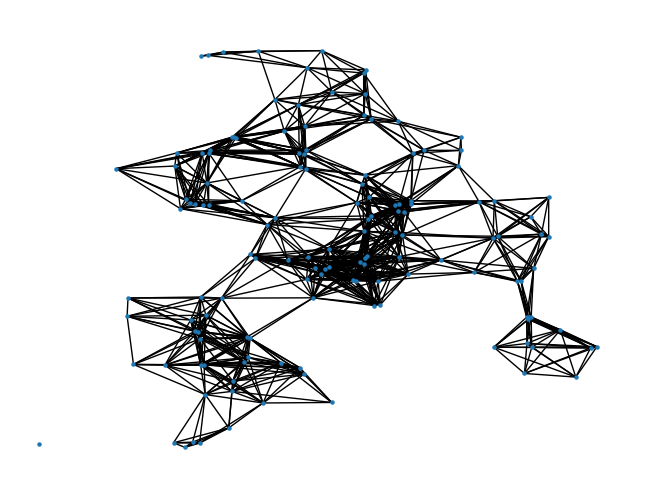

In [14]:
G = nx.Graph(W) # create a nx object

# Plot the input weighted graph.
nx.draw(G, pos=P, node_size=5)

## Scaffold

### Creating Minimal Scaffold

In [15]:
epsList = Geometry.genFullEpsList(W) # create list of filtration parameters

In [16]:
print(epsList)

[0.001, 3.001, 4.001, 5.001, 6.001, 7.001, 8.001, 9.001, 10.001, 11.001, 12.001, 13.001, 15.001, 16.001, 17.001, 18.001, 19.001, 20.001, 21.001, 22.001, 23.001, 24.001, 25.001, 26.001, 27.001, 28.001, 29.001, 30.001, 31.001, 32.001, 33.001, 34.001, 35.001, 36.001, 37.001, 38.001, 39.001, 40.001, 41.001, 42.001, 43.001, 44.001, 45.001, 46.001, 47.001, 48.001, 49.001, 50.001, 51.001, 52.001, 53.001, 54.001, 55.001, 56.001, 57.001, 58.001, 59.001, 60.001, 61.001, 62.001, 63.001, 64.001, 65.001, 66.001, 67.001, 68.001, 69.001, 70.001, 71.001, 72.001, 73.001, 74.001, 75.001, 76.001, 77.001, 78.001, 79.001, 80.001, 81.001, 82.001, 83.001, 84.001, 85.001, 86.001, 87.001, 88.001, 89.001, 90.001, 91.001, 92.001, 93.001, 94.001, 95.001, 96.001, 97.001, 98.001, 99.001, 100.001, 101.001, 102.001, 103.001, 104.001, 105.001, 106.001, 107.001, 108.001, 109.001, 110.001, 111.001, 112.001, 113.001, 114.001, 115.001, 116.001, 117.001, 118.001, 119.001, 120.001]


In [17]:
# compute minimal generators for each filtration value
F = Driver.getFiltrBasis(W, epsList, Draws=False, parallel=False, monitor=None)

In [18]:
numCyc = [x[1].card() for x in F.Elements]

epsLev = [x[0] for x in F.Elements]

In [19]:
#compute the adjacency matrix of the minimal scaffold.
S = Scaffold.frequency_Scaffold(F , len(P))

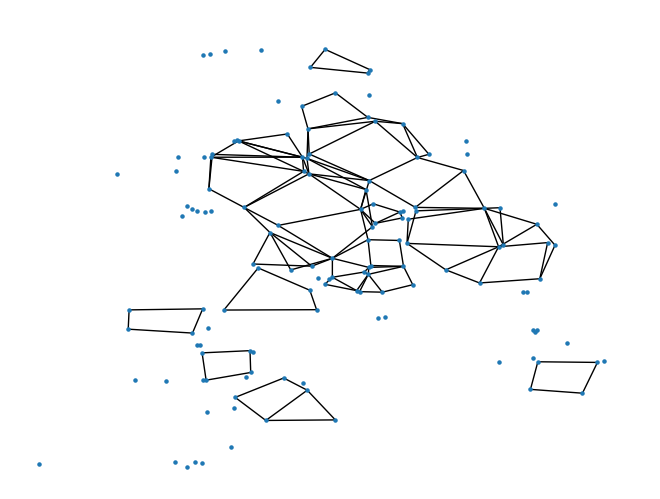

In [20]:
Scaf = nx.from_numpy_array(S, parallel_edges=False)
nx.draw(Scaf,pos=P, node_size=5)

### Exploring Bases

In [21]:
# Create a list of homology bases
Bas = []
for (step,B) in F.Elements: 
    Bas.append(B) # store the basis, discarding the filtration step value

In [23]:
# Load in zip file of grocery sites underneath 
zipfname = '../Dallas/Zip/dal_tx_zip.shp'
city_df = gpd.read_file(zipfname)

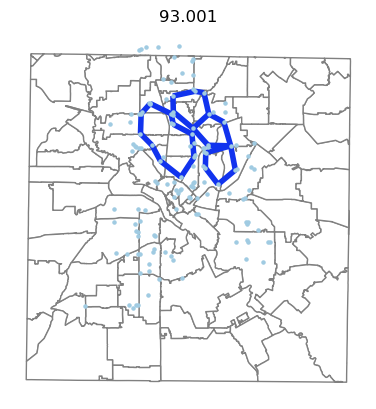

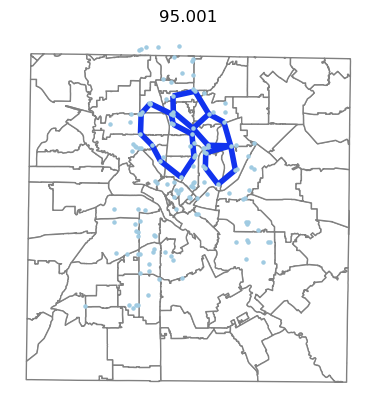

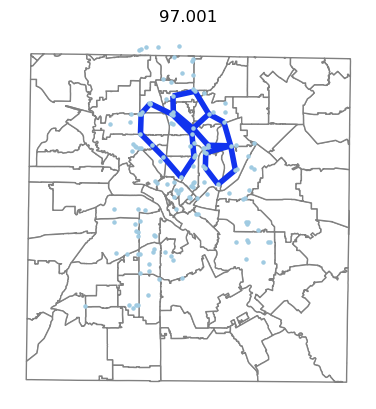

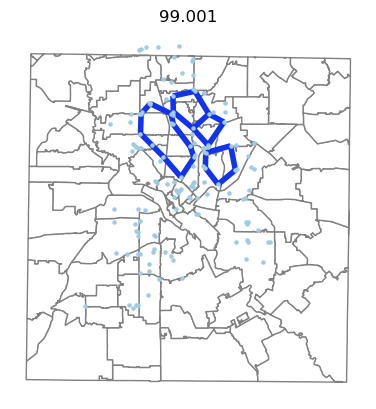

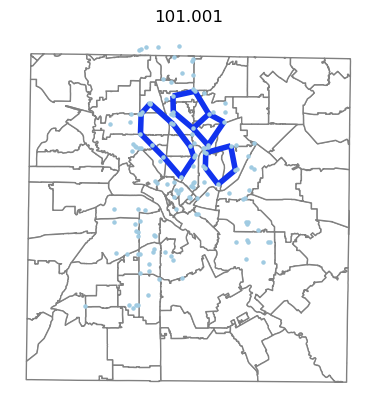

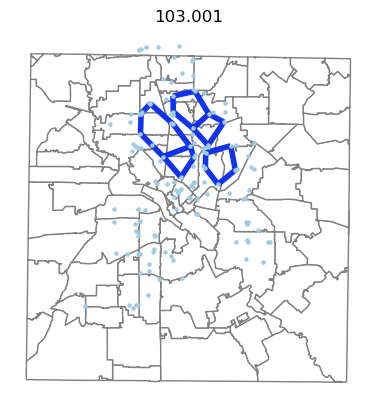

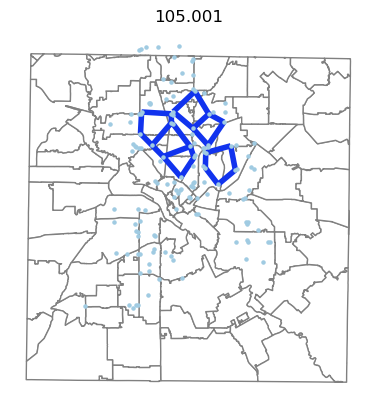

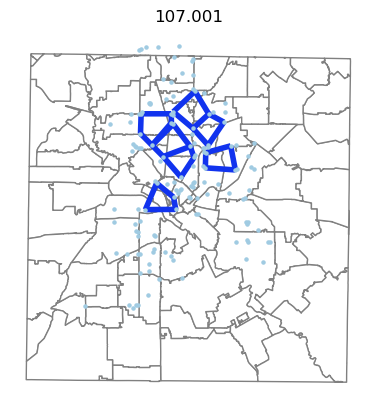

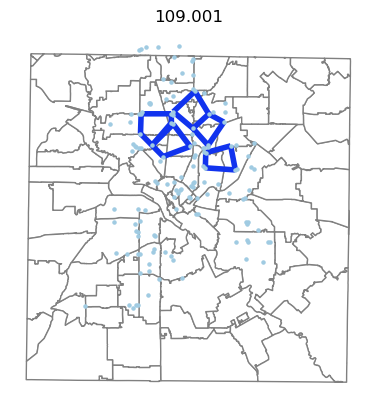

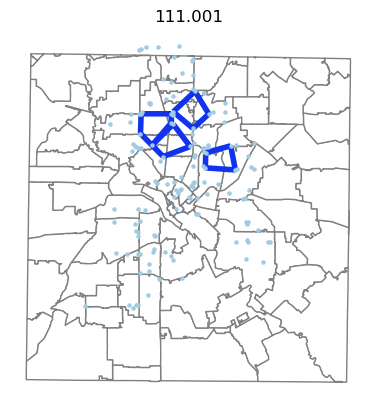

In [24]:
#Print selected minimal generators

np.set_printoptions(threshold=np.inf)
indices = 90+2*np.array(range(10))

colors = [1,2,3]
options = {
    "node_color": "#A0CBE2",
    "edge_color": "#1133EE",
    "width": 4,
    "edge_cmap": plt.cm.Blues,
    "with_labels": False,
}
edge_color_list = ["#1133EE","#6699EE","#AABBEE"]

# Depending on the length of the filtration, choose a suitable step that contains nontrivial homology
for j1 in range(len(indices)):
    fig , ax1= plt.subplots()
    city_df.plot(ax=ax1, color='white', edgecolor='grey')
    #options["edge_color"]=edge_color_list[np.mod(j1,3)]
    
    whichB = indices[j1]
    B = Bas[whichB]
    #print(P)
    #print(M)
    #print(whichB)
    M = Scaffold.matrix_Basis( B , len(P) , np.array(F.get_edgeList()) )
    
    
    # Plot the basis at the given step, using the layout object as done above
    nx.draw( nx.Graph(M) , pos = P , node_size=5, **options, ax=ax1)
    S = [nx.Graph(M).subgraph(c).copy() for c in nx.connected_components(nx.Graph(M))]
    plt.title(epsLev[whichB])
    #plt.savefig(f'../Cycles_Dallas/dal_tx_MinCycles_{dist_type}_{str(whichB)}.jpeg', \
                #bbox_inches="tight", dpi = 300)
    plt.show()
    

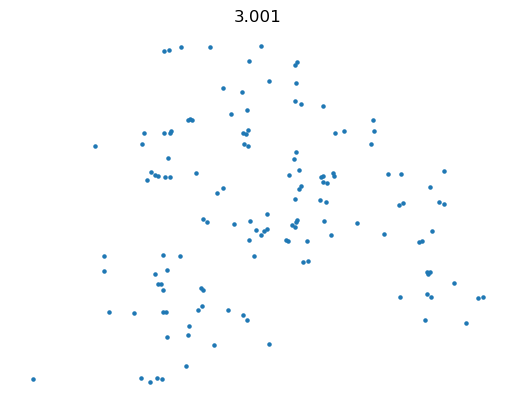

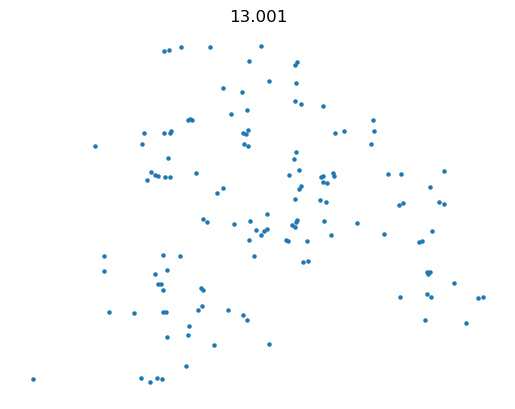

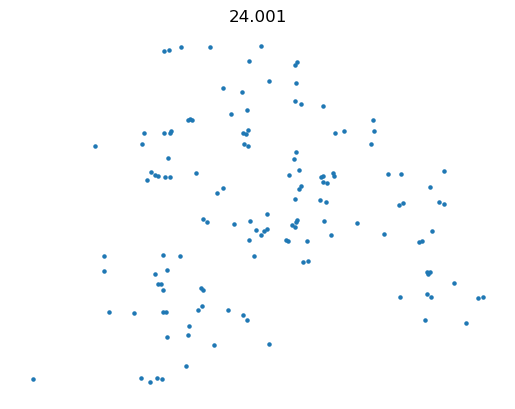

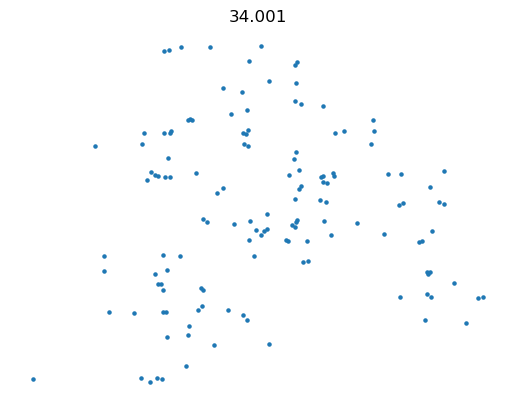

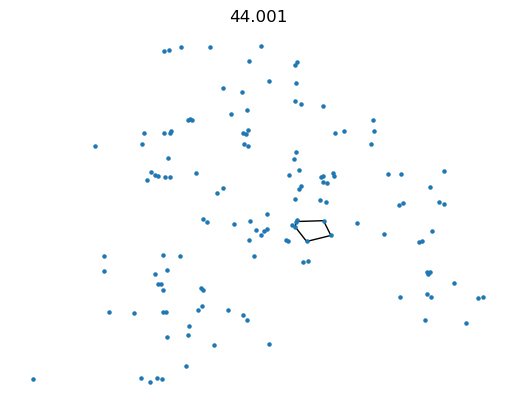

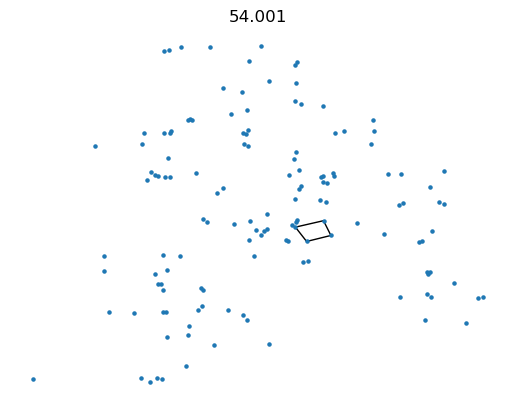

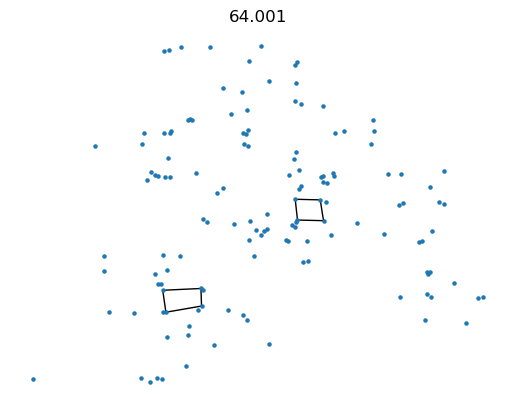

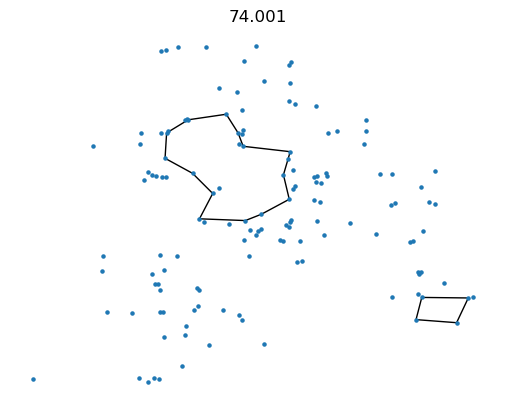

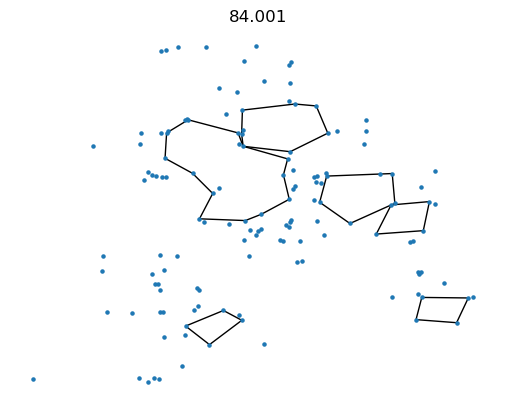

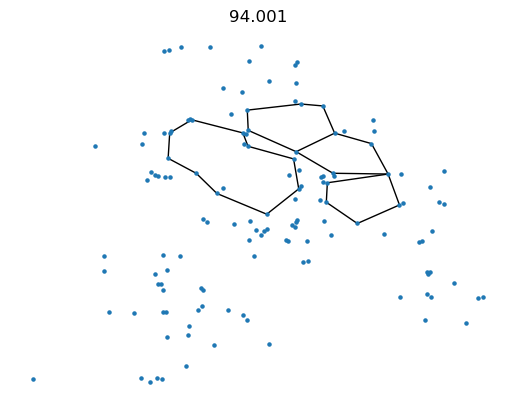

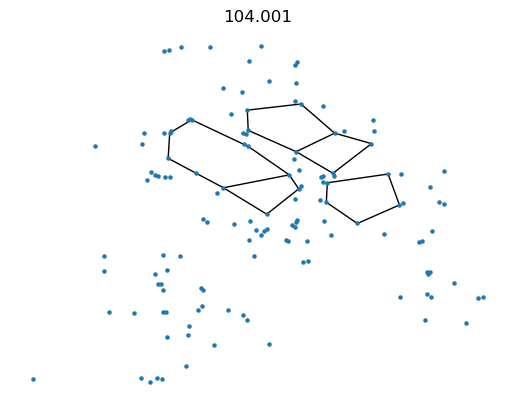

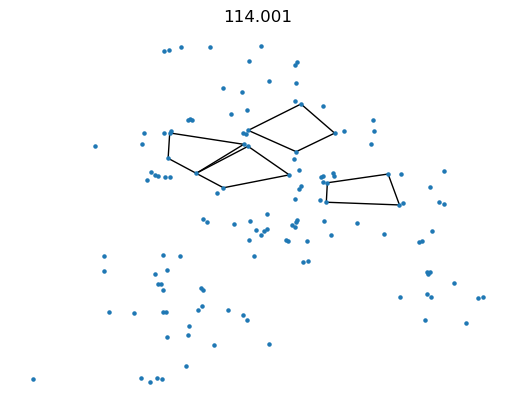

In [25]:
# Print selected minimal generators
i = 0
for (e,B) in F.Elements:
    i += 1
    if np.mod(i,10)==1:
        fig , ax1= plt.subplots()
        M = Scaffold.matrix_Basis( B , len(P) , np.array(F.get_edgeList()) )
        nx.draw( nx.Graph(M) , pos = P , node_size=5, ax=ax1 )
        plt.title(epsLev[i])
        plt.show()

## Visualizing Holes using Shapely

In [26]:
# In polygons_list, store list of vertices that make up each hole

np.set_printoptions(threshold=np.inf)
indices = range(len(epsList))

polygons_list = [];
for j1 in range(len(indices)):
    whichB = indices[j1]
    B = Bas[whichB]
    M = Scaffold.matrix_Basis( B , len(P) , np.array(F.get_edgeList()) )
    S = [nx.Graph(M).subgraph(c).copy() for c in nx.connected_components(nx.Graph(M))]
    polygons = []
    for component in S:
        if len(component.nodes) > 1:
            path = []
            cycle = nx.find_cycle(component)
            for edge in cycle: 
                path.append(edge[0])
            polygons.append(path)
    polygons_list.append(polygons)

In [29]:
# Load Census block geography (will be needed for population)
blockfname = '../Dallas/Block/dal_tx_block.shp'
# Geography files
# - why provide full path: we have multiple resources. 
# - ZIP codes make more sense to provide in "resource ID agnostic" location
pfname = '../Dallas/Food access_updated/geo_export_872fcb6c-fbde-4264-ae77-8858a604ed0e.shp'
zipfname = '../Dallas/Zip/dal_tx_zip.shp'

In [30]:
block_df = gpd.read_file(blockfname)
groc_df  = gpd.read_file(pfname)
zip_df = gpd.read_file(zipfname)

In [31]:
sqm_to_sqmi_convert = 2589988

# Assuming "ALAND' and "POP20" are accurate:
block_df['PopDens']=block_df['POP20']/block_df['ALAND20']*sqm_to_sqmi_convert

In [32]:
# Coordinate systems
meters_per_mile = 1609.34
crs = {
    'census': 'EPSG:4269'  , # degrees - used by Census
    'projected': 'EPSG:3083',         # projected; needed for maup
    'area'  : 'ESRI:102003', # meters
    'length': 'ESRI:102005', # meters
}
'''
EPSG:3083
Coordinate System: 	
Cartesian 2D CS. Axes: easting, northing (X,Y). 
Orientations: east, north. UoM: m.Open
Base CRS: 	
NAD83Open
Conversion: 	
Texas Centric Albers Equal Area
'''

'\nEPSG:3083\nCoordinate System: \t\nCartesian 2D CS. Axes: easting, northing (X,Y). \nOrientations: east, north. UoM: m.Open\nBase CRS: \t\nNAD83Open\nConversion: \t\nTexas Centric Albers Equal Area\n'

In [33]:
# Project all into CRS
block_df.geometry = block_df.geometry.to_crs(crs['projected'])
groc_df.geometry = groc_df.geometry.to_crs(crs['projected'])

In [34]:
geo_walk_conversion_rate = 1.14 # adjustment factor to compensate for walking distance being longer than geodesic distance

93.001
1980.9213


/opt/anaconda3/lib/python3.13/site-packages/shapely/set_operations.py:553: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/shapely/set_operations.py:100: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/shapely/set_operations.py:553: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/var/folders/ll/qvm14v2x0nj_0wnpjp3x8syw0000gn/T/ipykernel_15519/1254198890.py:40: UserWarning: The indices of the left

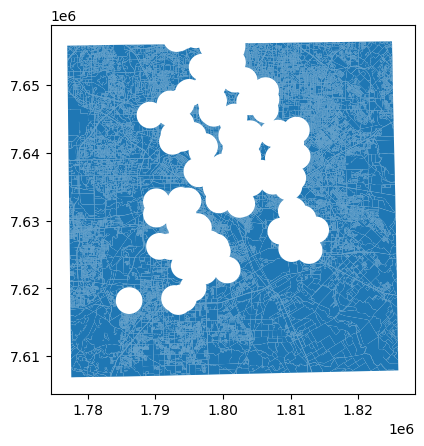

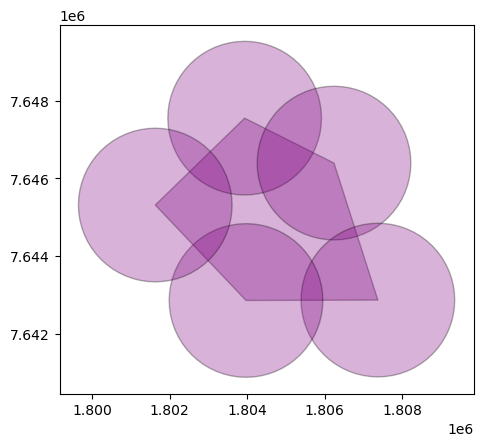

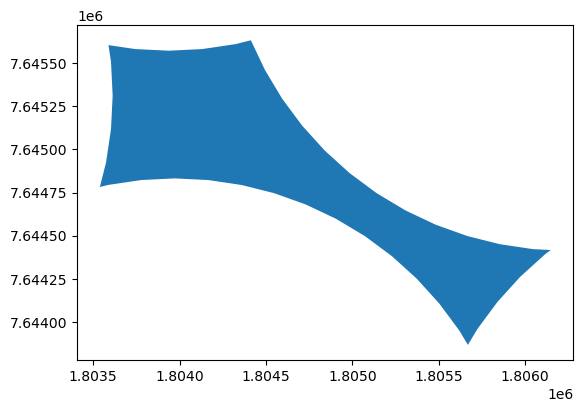

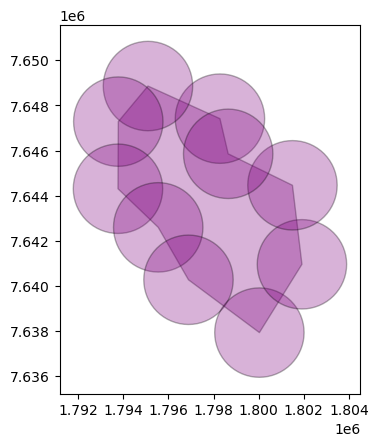

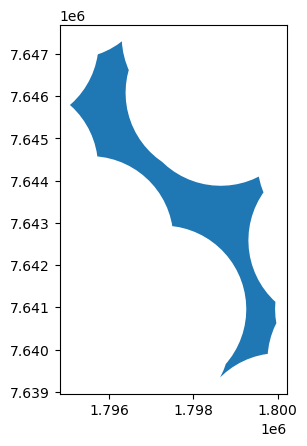

In [38]:
# Visualize holes for a given index
indices = [90]
for i in indices:
    print(epsList[i])
    if dist_type == 'walk':
        radius_serv_area = epsList[i] * 60 * walk_speed / (4 * geo_walk_conversion_rate)
    elif dist_type == 'geodesic':
        radius_serv_area = epsList[i] * 60 * walk_speed / 4
    print(radius_serv_area)
    service_areas = groc_df.geometry.buffer(radius_serv_area)
    service_areas_all = service_areas.union_all()
    service_area_holes = block_df.geometry.intersection(service_areas_all)
    county_with_holes = block_df['geometry'].difference(service_area_holes)
    county_with_holes.plot()
    county_with_holes_union = county_with_holes
    for poly in polygons_list[i]:
        groc_df_lim = groc_df.loc[poly]
        min_cycle_area = Polygon(groc_df_lim['geometry'])
        list_of_areas = [min_cycle_area]
        for l in poly:
            service_area_pt = groc_df.loc[l].geometry.buffer(radius_serv_area)
            list_of_areas.append(service_area_pt)
        service_areas_lim = groc_df_lim.geometry.buffer(radius_serv_area)
        service_areas_all_lim = service_areas_lim.union_all()
        service_area_holes_lim = block_df.geometry.intersection(service_areas_all_lim)
        #min_cycle_area = Polygon(groc_df_lim['geometry'])
        min_cycle_df = gpd.GeoDataFrame(data = [[poly]], \
                                geometry=gpd.GeoSeries(min_cycle_area),\
                               crs=crs['projected'])
        min_cycle_df=min_cycle_df.rename(columns={0:'Cycle vertices'})
        #shapes = gpd.GeoSeries([min_cycle_area, service_areas_all_lim])
        shapes = gpd.GeoSeries(list_of_areas)
        shapes.plot(color='purple',alpha = 0.3,edgecolor='k')
        #min_cycle_df.plot()
        county_with_holes_union = county_with_holes_union.geometry.union(min_cycle_df)
        cycle_holes = min_cycle_df.geometry.intersection(service_areas_all)
        cycle_with_holes = min_cycle_df.difference(cycle_holes)
        cycle_with_holes.plot()